# MNIST VAE 生成示例
本 Notebook 使用变分自编码器（VAE）在 MNIST 上训练，并从潜变量空间采样生成手写数字。


## 1) 环境检查与依赖准备
这段代码检查并准备 `torch`、`torchvision`、`matplotlib`、`tqdm`，确保后续训练代码可执行。


In [1]:
import importlib.util
import subprocess
import sys


def ensure_packages(packages):
    missing = [p for p in packages if importlib.util.find_spec(p) is None]
    if not missing:
        print("???????")
        return True

    print(f"???????: {missing}???????...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
        print("???????")
        return True
    except Exception as e:
        print("????????????????")
        print(f"????: {e}")
        return False

DEPENDENCIES_READY = ensure_packages(["torch", "torchvision", "matplotlib", "tqdm"])


???????


## 2) 导入库与训练配置
这段代码导入训练所需库，设置随机种子、设备和超参数。


In [2]:
if DEPENDENCIES_READY:
    import random
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader
    from torchvision import datasets, transforms
    import matplotlib.pyplot as plt
    from tqdm.auto import tqdm

    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"????: {device}")

    batch_size = 128
    lr = 1e-3
    num_epochs = 5
    latent_dim = 16
else:
    print("???????????????????????")


????: cuda


c:\Users\napuc\anaconda3\envs\npcailab\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3) 加载 MNIST 数据
这段代码读取 MNIST 训练集，并保持像素在 `[0,1]`，便于使用 BCE 重构损失。


In [3]:
if DEPENDENCIES_READY:
    transform = transforms.ToTensor()
    train_set = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
    print(f"?????: {len(train_set)}")


?????: 60000


## 4) 定义 VAE 网络
这段代码实现编码器、重参数化采样和解码器，输出重构图像及潜变量分布参数。


In [4]:
if DEPENDENCIES_READY:
    class VAE(nn.Module):
        def __init__(self, x_dim=28*28, h_dim=512, z_dim=16):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(x_dim, h_dim),
                nn.ReLU(),
                nn.Linear(h_dim, h_dim),
                nn.ReLU(),
            )
            self.fc_mu = nn.Linear(h_dim, z_dim)
            self.fc_logvar = nn.Linear(h_dim, z_dim)

            self.decoder = nn.Sequential(
                nn.Linear(z_dim, h_dim),
                nn.ReLU(),
                nn.Linear(h_dim, h_dim),
                nn.ReLU(),
                nn.Linear(h_dim, x_dim),
                nn.Sigmoid(),
            )

        def encode(self, x):
            h = self.encoder(x)
            return self.fc_mu(h), self.fc_logvar(h)

        def reparameterize(self, mu, logvar):
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std

        def decode(self, z):
            return self.decoder(z)

        def forward(self, x):
            mu, logvar = self.encode(x)
            z = self.reparameterize(mu, logvar)
            x_hat = self.decode(z)
            return x_hat, mu, logvar


    def vae_loss(x_hat, x, mu, logvar):
        bce = F.binary_cross_entropy(x_hat, x, reduction="sum")
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return bce + kld, bce, kld


    model = VAE(z_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    print(f"?????: {sum(p.numel() for p in model.parameters()):,}")


?????: 1,354,544


## 5) 训练 VAE
这段代码联合优化重构误差和 KL 散度，使潜空间接近标准高斯并保留图像信息。


In [5]:
if DEPENDENCIES_READY:
    model.train()
    for epoch in range(num_epochs):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        total_loss = 0.0

        for x, _ in pbar:
            x = x.to(device).view(x.size(0), -1)
            x_hat, mu, logvar = model(x)
            loss, bce, kld = vae_loss(x_hat, x, mu, logvar)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item()/x.size(0):.4f}")

        mean_loss = total_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1}: mean loss per sample = {mean_loss:.4f}")


Epoch 1/5:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 1/5: 100%|██████████| 468/468 [00:11<00:00, 39.77it/s, loss=132.5267]


Epoch 1: mean loss per sample = 169.2247


Epoch 2/5: 100%|██████████| 468/468 [00:10<00:00, 42.94it/s, loss=122.7436]


Epoch 2: mean loss per sample = 123.3762


...

Epoch 3: mean loss per sample = 115.1708


Epoch 4/5: 100%|██████████| 468/468 [00:10<00:00, 43.60it/s, loss=105.8977]


Epoch 4: mean loss per sample = 111.2562


Epoch 5/5: 100%|██████████| 468/468 [00:10<00:00, 42.90it/s, loss=108.5944]

Epoch 5: mean loss per sample = 108.8187


## 6) 从潜空间采样并生成数字
这段代码从标准高斯采样潜变量 `z`，通过解码器直接生成新的手写数字图像。


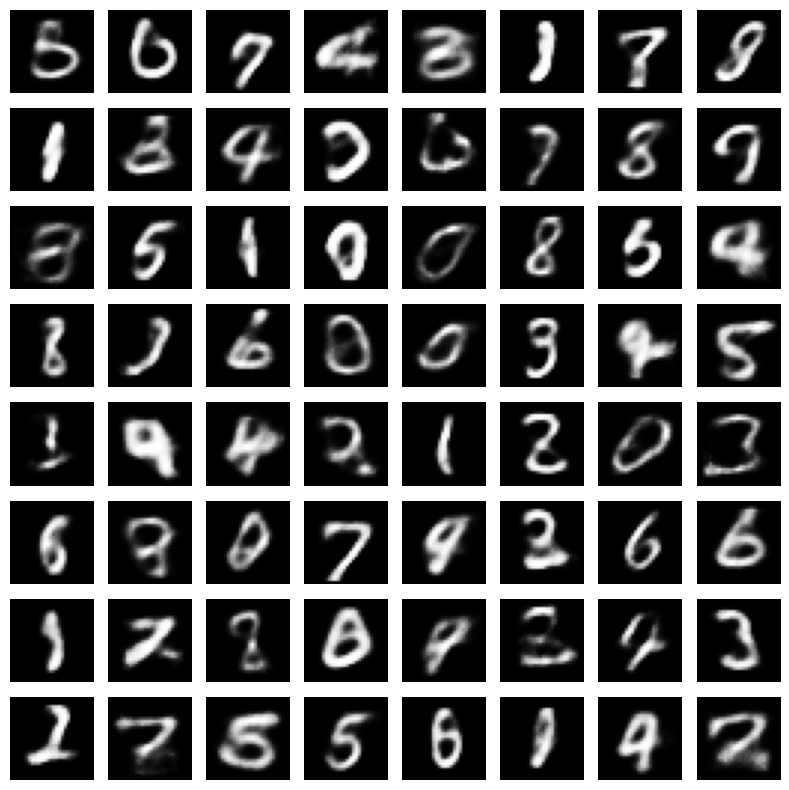

In [6]:
if DEPENDENCIES_READY:
    @torch.no_grad()
    def sample_vae(model, n_samples=64, z_dim=16):
        model.eval()
        z = torch.randn(n_samples, z_dim, device=device)
        x = model.decode(z)
        x = x.view(-1, 1, 28, 28)
        return x.cpu()


    samples = sample_vae(model, n_samples=64, z_dim=latent_dim)

    fig, axes = plt.subplots(8, 8, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i, 0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 7) 重构效果可视化（可选）
这段代码展示真实图像与重构图像的对比，便于快速判断模型学习效果。


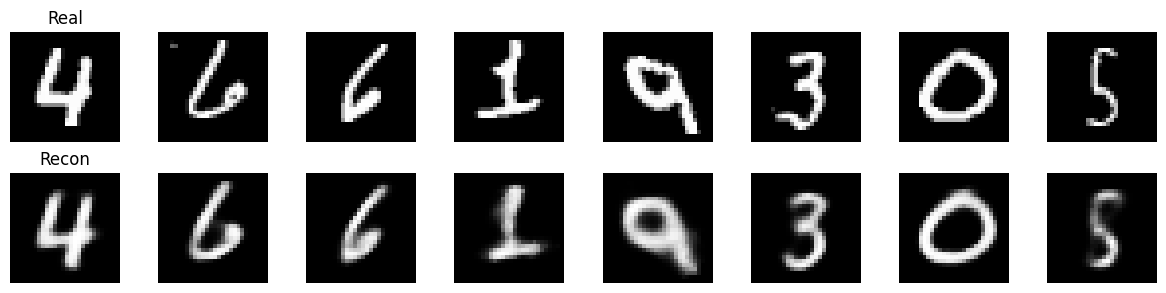

In [7]:
if DEPENDENCIES_READY:
    model.eval()
    x, _ = next(iter(train_loader))
    x = x.to(device)[:8]
    with torch.no_grad():
        x_hat, _, _ = model(x.view(x.size(0), -1))

    x_hat = x_hat.view(-1, 1, 28, 28).cpu()
    x = x.cpu()

    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i in range(8):
        axes[0, i].imshow(x[i, 0], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_hat[i, 0], cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_title("Real")
    axes[1, 0].set_title("Recon")
    plt.tight_layout()
    plt.show()


## 8) 保存模型（可选）
这段代码把训练完成的 VAE 参数保存到本地。


In [8]:
if DEPENDENCIES_READY:
    save_path = "vae_mnist.pt"
    torch.save(model.state_dict(), save_path)
    print(f"??????: {save_path}")


??????: vae_mnist.pt
